# Objectif 

Ce notebook fait suite au transfert des données par Jean-Michel le 02/10/2026. 

L'objectif est pre-process les données. Pour cela l'ensemble des données est converti au format netcdf via xarray. 

Fichiers d'entrée (données brutes): 

* Fichiers de position :
    * Position de l'ATALANTE au cours de la campagne : Trame_GPS_ATL
    * Position de la source lors de chacun des tirs : SHOT (ACOU_ShotPoint001_1.asc)
    * Position AIS : AIS_LPLNE.csv
    * Position des récepteurs : OBS_TLQ_POS.csv


* Fichiers de pression : fichiers binaires des dossiers PRESSURE/OBSi

Fichiers de sortie (après processing) :

* Données de positions : acouplane_pos.nc
* Données de pression : acouplane_pressure.nc

Date de création : 03/10/2026

In [1]:
import os
import sys
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.io import loadmat
from datetime import datetime, timedelta

In [2]:
ROOT_PROGRAM = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"
sys.path.append(ROOT_PROGRAM)
from publication.publication_figure import set_subfigures_abc_labels, color
from real_data_analysis.acouplane.src.acouplane_cst import *
from real_data_analysis.acouplane.src.acouplane_utils import *
from get_data.obs_bin.obs_reader_acouplane import read_obs_data

# Données de position

## Chargement des données 

### Position des récepteurs 

In [3]:
# Read OBS pos
df_rcv_pos = pd.read_csv(
    OBS_TLQ_POS_FPATH,
    dtype={
        "id": str,
        "lon": np.float64,
        "lat": np.float64,
    },
)
df_rcv_pos

,id,lon,lat
0,obs1,5.9526,43.0160
1,obs2,5.9526,43.0170
2,obs4,5.9360,43.0165
3,obs5,5.9930,43.0100
4,obs6,6.0506,42.9440
5,obs7,5.9695,43.0545
6,tlq,5.9695,43.0553


### Trajectoire ATALANTE

In [4]:
files_ATL_mat = sorted(
    glob.glob(
        os.path.join(ACOUPLANE_DATA_POSITION_TRAME_GPS_ATL_DIR, f"*.mat")
    )
)
# print(files_ATL_mat)

time_atl_dt = []
lat_atl_pos = []
lon_atl_pos = []

for fmat in files_ATL_mat:
    atl = loadmat(fmat)["res"]
    # Extract info from mat file
    lat_atl_pos_i, lon_atl_pos_i, time_atl_matlab_i = (
        atl[:, 0],
        atl[:, 1],
        atl[:, 2],
    )
    # Convert time from MATLAB datenum to datetime
    time_atl_dt_i = pd.to_datetime(time_atl_matlab_i - 719529, unit="D", origin="1970-01-01")
    # Drop duplicates if any 
    time_atl_dt_i, idx = np.unique(time_atl_dt_i, return_index=True)
    lon_atl_pos_i = lon_atl_pos_i[idx]
    lat_atl_pos_i = lat_atl_pos_i[idx]
    # print(time_atl_dt_i, lat_atl_pos_i, lon_atl_pos_i)

    # Store 
    time_atl_dt.append(time_atl_dt_i)
    lon_atl_pos.append(lon_atl_pos_i)
    lat_atl_pos.append(lat_atl_pos_i)

# Convert to numpy array
time_atl_dt = np.concat(time_atl_dt)
lon_atl_pos = np.concat(lon_atl_pos)
lat_atl_pos = np.concat(lat_atl_pos)

idx_sort_dt = np.argsort(time_atl_dt)
time_atl_dt = time_atl_dt[idx_sort_dt]
lon_atl_pos = lon_atl_pos[idx_sort_dt]
lat_atl_pos = lat_atl_pos[idx_sort_dt]

# Convert to dataframe
df_atl = pd.DataFrame.from_dict(
    {"datetime": time_atl_dt, "longitude": lon_atl_pos, "latitude": lat_atl_pos},
)
df_atl

,datetime,longitude,latitude
0,2026-02-24 00:00:00.000000000,5.946851,43.028906
1,2026-02-24 00:00:01.000004633,5.946819,43.028906
2,2026-02-24 00:00:01.999999209,5.946787,43.028905
3,2026-02-24 00:00:03.000003842,5.946755,43.028904
4,2026-02-24 00:00:03.999998419,5.946723,43.028903
...,...,...,...
563734,2026-03-02 16:01:02.000002336,5.884835,43.105674
563735,2026-03-02 16:01:02.999996912,5.884835,43.105674
563736,2026-03-02 16:01:04.000001545,5.884835,43.105674
563737,2026-03-02 16:01:04.999996122,5.884835,43.105674


### Données AIS 

In [5]:
def load_ais():
    df_ais = pd.read_csv(
        AIS_FPATH,
        delimiter=";",
        header=0,
        names=["mmsi", "datetime", "lon", "lat"],
    )
    # Convert datatime columns from str to datetime
    fmt = "%d/%m/%Y %H:%M"
    df_ais["datetime"] = pd.to_datetime(df_ais["datetime"], format=fmt)
    # Change dtypes
    df_ais["mmsi"] = df_ais["mmsi"].astype(int)

    # Remove AIS lines with unique positions (at least two points to define a trajectory)
    df_ais = df_ais.groupby("mmsi").filter(lambda x: len(x) > 1)

    # Remove duplicates if any
    df_ais = df_ais.drop_duplicates()

    # Sort 

    return df_ais

In [6]:
def format_ais_data(ais_interp, mmsi, t_start, t_end, time_step):

    t_start = t_start - pd.Timedelta(time_step)
    t_end = t_end + pd.Timedelta(time_step)
    # Define common time vector
    common_time = pd.date_range(start=t_start, end=t_end, freq=time_step)

    ais_lon_mat = []
    ais_lat_mat = []

    for mmsi_i in mmsi:

        ais_mmsi = ais_interp.loc[ais_interp["mmsi"] == mmsi_i]
        # Sort by datetime 
        ais_mmsi = ais_mmsi.sort_values(by="datetime")

        ais_mmsi_arr = ais_mmsi.to_numpy(dtype=np.float64)[
            :, 2:4
        ]  # Exclude time and mmsi column

        # Pad lon lat with NaNs to match common_time length
        try:
            n_pad_start = (ais_mmsi["datetime"].iloc[0] - t_start) // pd.Timedelta(
                time_step
            )
            n_pad_end = (t_end - ais_mmsi["datetime"].iloc[-1]) // pd.Timedelta(time_step)
            ais_mmsi_arr = np.pad(
                ais_mmsi_arr,
                ((n_pad_start, n_pad_end), (0, 0)),
                mode="constant",
                constant_values=np.nan,
            )
        except:
            print(mmsi_i, ais_mmsi)
            continue

        # Add to array
        ais_lon_mat.append(ais_mmsi_arr[:, 0])
        ais_lat_mat.append(ais_mmsi_arr[:, 1])

    ais_lon_mat = np.array(ais_lon_mat)
    ais_lat_mat = np.array(ais_lat_mat)

    return ais_lon_mat, ais_lat_mat, common_time

In [7]:
from source.utils.utils_ais import interpolate_ais
time_step = "10s"
df_ais = load_ais()
df_ais, mmsi = interpolate_ais(ais=df_ais, time_step=time_step)
df_ais

Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%

,datetime,lon,lat,mmsi
0,2026-02-27 18:23:00,6.372540,43.136820,4
1,2026-02-27 18:23:10,6.372540,43.136820,4
2,2026-02-27 18:23:20,6.372540,43.136820,4
3,2026-02-27 18:23:30,6.372540,43.136820,4
4,2026-02-27 18:23:40,6.372540,43.136820,4
...,...,...,...,...
8140559,2026-03-01 15:06:20,5.759778,43.132174,244
8140560,2026-03-01 15:06:30,5.759594,43.132293,244
8140561,2026-03-01 15:06:40,5.759411,43.132412,244
8140562,2026-03-01 15:06:50,5.759227,43.132531,244


In [9]:
t_start, t_end = df_ais.datetime.min(), df_ais.datetime.max()
print(t_start, t_end)
ais_lon_mat, ais_lat_mat, ais_datetime = format_ais_data(
    ais_interp=df_ais, mmsi=mmsi, t_start=t_start, t_end=t_end, time_step=time_step
)

2026-02-24 00:00:00 2026-03-02 23:54:00


### Positions des tirs sismiques 

In [10]:
files_shot_asc = glob.glob(os.path.join(ACOUPLANE_DATA_POSITION_SHOT_DIR, f"*.asc"))

def asc_to_df(fasc):
    df_shot = pd.read_csv(
        fasc,
        delimiter="\t",
        header=0,
        names=[
            "SEGD",
            "ECOS",
            "date",
            "shot_time",
            "lon_vessel",
            "lat_vessel",
            "lon_source",
            "lat_source",
        ],
        dtype={
            "SEGD": int,
            "ECOS": int,
            "lon_vessel": np.float64,
            "lat_vessel": np.float64,
            "lon_source": np.float64,
            "lat_source": np.float64,
        },
    )

    # Convert date and time to datetime single column
    shot_datetime_str = df_shot["date"] + " " + df_shot["shot_time"]
    fmt = "%d/%m/%Y %H:%M:%S.%f"
    try:
        df_shot["shot_datetime"] = pd.to_datetime(shot_datetime_str, format=fmt)
    except:
        print(fasc)
    # Drop columns
    df_shot = df_shot.drop(columns=["date", "shot_time"])
    return df_shot

df_shot = []

for fasc in files_shot_asc:
    df_shot_i = asc_to_df(fasc)
    df_shot.append(df_shot_i)

df_shot = pd.concat(df_shot)
# Sort by date
df_shot = df_shot.sort_values(by="shot_datetime")
df_shot

,SEGD,ECOS,lon_vessel,lat_vessel,lon_source,lat_source,shot_datetime
0,1,1,6.023298,43.003975,6.024248,43.004038,2026-02-24 20:14:06.600098
1,2,2,6.023214,43.003968,6.024163,43.004031,2026-02-24 20:14:09.600098
2,3,3,6.023129,43.003962,6.024079,43.004024,2026-02-24 20:14:12.600098
3,4,4,6.023044,43.003955,6.023994,43.004017,2026-02-24 20:14:15.600098
4,5,5,6.022960,43.003949,6.023910,43.004010,2026-02-24 20:14:18.600098
...,...,...,...,...,...,...,...
17,19,18,5.994799,43.016170,5.994527,43.015500,2026-02-27 05:28:30.200073
18,20,19,5.994916,43.016951,5.994632,43.016276,2026-02-27 05:29:00.200073
19,21,20,5.995043,43.017730,5.994748,43.017053,2026-02-27 05:29:30.200073
20,22,21,5.995154,43.018508,5.994877,43.017824,2026-02-27 05:30:00.200073


## Merge de l'ensemble des données 

In [11]:
df_rcv_pos

,id,lon,lat
0,obs1,5.9526,43.0160
1,obs2,5.9526,43.0170
2,obs4,5.9360,43.0165
3,obs5,5.9930,43.0100
4,obs6,6.0506,42.9440
5,obs7,5.9695,43.0545
6,tlq,5.9695,43.0553


In [12]:
df_atl.dtypes, df_ais.dtypes, df_shot.dtypes

(datetime     datetime64[ns]
 longitude           float64
 latitude            float64
 dtype: object,
 datetime    datetime64[us]
 lon                float64
 lat                float64
 mmsi                 int64
 dtype: object,
 SEGD                      int64
 ECOS                      int64
 lon_vessel              float64
 lat_vessel              float64
 lon_source              float64
 lat_source              float64
 shot_datetime    datetime64[us]
 dtype: object)

In [13]:
df_ais.mmsi

0            4
1            4
2            4
3            4
4            4
          ... 
8140559    244
8140560    244
8140561    244
8140562    244
8140563    244
Name: mmsi, Length: 8140564, dtype: int64

In [15]:
ds_pos = xr.Dataset(
    data_vars=dict(
        # RCV pos
        rcv_lon=(["rcv_id"], df_rcv_pos.lon),
        rcv_lat=(["rcv_id"], df_rcv_pos.lat),
        # ATL pos
        atl_lon=(["atl_datetime"], df_atl.longitude),
        atl_lat=(["atl_datetime"], df_atl.latitude),
        # AIS pos
        ais_lon=(["mmsi", "ais_datetime"], ais_lon_mat),
        ais_lat=(["mmsi", "ais_datetime"], ais_lat_mat),
        # Tirs source
        tir_src_lon=(["src_datetime"], df_shot.lon_source),
        tir_SEGD=(["src_datetime"], df_shot.SEGD),
        tir_ECOS=(["src_datetime"], df_shot.ECOS),
        tir_src_lat=(["src_datetime"], df_shot.lat_source),
        tir_vessel_lon=(["src_datetime"], df_shot.lon_vessel),
        tir_vessel_lat=(["src_datetime"], df_shot.lat_vessel),
    ),
    coords=dict(
        rcv_id=df_rcv_pos.id.str.upper(),
        ais_datetime=ais_datetime,
        atl_datetime=df_atl.datetime,
        src_datetime=df_shot.shot_datetime,
    ),
    attrs=dict(
        description="Positions AIS interpolées",
        interpolation_time_step=time_step,
        campagne="ACOUPLANE",
        geodesic_frame="WGS84",
    ),
)

In [16]:
ds_pos

<xarray.Dataset> Size: 525MB
Dimensions:         (rcv_id: 7, atl_datetime: 563739, mmsi: 526,
                     ais_datetime: 60447, src_datetime: 33608)
Coordinates:
  * rcv_id          (rcv_id) object 56B 'OBS1' 'OBS2' 'OBS4' ... 'OBS7' 'TLQ'
  * atl_datetime    (atl_datetime) datetime64[ns] 5MB 2026-02-24 ... 2026-03-...
  * ais_datetime    (ais_datetime) datetime64[us] 484kB 2026-02-23T23:59:50 ....
  * src_datetime    (src_datetime) datetime64[us] 269kB 2026-02-24T20:14:06.6...
Dimensions without coordinates: mmsi
Data variables:
    rcv_lon         (rcv_id) float64 56B 5.953 5.953 5.936 5.993 6.051 5.97 5.97
    rcv_lat         (rcv_id) float64 56B 43.02 43.02 43.02 ... 42.94 43.05 43.06
    atl_lon         (atl_datetime) float64 5MB 5.947 5.947 5.947 ... 5.885 5.885
    atl_lat         (atl_datetime) float64 5MB 43.03 43.03 43.03 ... 43.11 43.11
    ais_lon         (mmsi, ais_datetime) float64 254MB nan nan nan ... nan nan
    ais_lat         (mmsi, ais_datetime) float64 254MB nan nan nan ... nan nan
    tir_src_lon     (src_datetime) float64 269kB 6.024 6.024 ... 5.995 5.995
    tir_SEGD        (src_datetime) int64 269kB 1 2 3 4 5 6 ... 18 19 20 21 22 23
    tir_ECOS        (src_datetime) int64 269kB 1 2 3 4 5 6 ... 17 18 19 20 21 22
    tir_src_lat     (src_datetime) float64 269kB 43.0 43.0 43.0 ... 43.02 43.02
    tir_vessel_lon  (src_datetime) float64 269kB 6.023 6.023 ... 5.995 5.995
    tir_vessel_lat  (src_datetime) float64 269kB 43.0 43.0 43.0 ... 43.02 43.02
Attributes:
    description:              Positions AIS interpolées
    interpolation_time_step:  10s
    campagne:                 ACOUPLANE
    geodesic_frame:           WGS84

In [17]:
ds_pos.to_netcdf(ACOUPLANE_POSITIONS_NC_FPATH)

# Données de pression

## Chargement des données 

In [3]:
# Read all OBS data from a main folder containing subfolders for each OBS
# data_folder = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\ACOUPLANE\DATA\PRESSURE\BIN"
obs_data, obs_time, fullScale = read_obs_data(
    data_folder=ACOUPLANE_DATA_PRESSURE_BIN_DIR, read_raw=True, verbose=True
)

Reading OBS data from folder: C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\ACOUPLANE\DATA\PRESSURE\BIN\OBS1
Reading file: C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\ACOUPLANE\DATA\PRESSURE\BIN\OBS1\ELOBS_D-3042301_TB_1455972318000000-1455997319874500_channel3_2026-03-02-09-52-44_002.bin
Recording from 24/02/2026 12:45:00 to 24/02/2026 19:41:41
Reading file: C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\ACOUPLANE\DATA\PRESSURE\BIN\OBS1\ELOBS_D-3042301_TB_1455997319875000-1456022325999500_channel3_2026-03-02-09-52-44_002.bin
Recording from 24/02/2026 19:41:41 to 25/02/2026 02:38:27
Reading OBS data from folder: C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\ACOUPLANE\DATA\PRESSURE\BIN\OBS2
Reading file: C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\ACOUPLANE\DATA\PRESSURE\BIN\OBS2\ELOBS_D-3042919_TB_1455973218000000-1455998225124500_channel3_2026-03-02-11-21-29_002.bin
Recording from 24/02/2026 13:00:00 to 24/02/2026 19:56:47
Reading file: C:\Users\baptiste.me

In [4]:
obs_data

{'OBS1': array([36745216, 27983360, 17442048, ..., 29645568, 53780224, 47517696],
       shape=(100014000,), dtype=int32),
 'OBS2': array([21543424, 25940736, 31615232, ..., 25755392, 32612864, 32611840],
       shape=(100034000,), dtype=int32)}

In [5]:
obs_time

{'OBS1': array(['2026-02-24T12:45:00.000000', '2026-02-24T12:45:00.000500',
        '2026-02-24T12:45:00.001000', ..., '2026-02-25T02:38:26.998500',
        '2026-02-25T02:38:26.999000', '2026-02-25T02:38:26.999500'],
       shape=(100014000,), dtype='datetime64[us]'),
 'OBS2': array(['2026-02-24T13:00:00.000000', '2026-02-24T13:00:00.000500',
        '2026-02-24T13:00:00.001000', ..., '2026-02-25T02:53:36.998500',
        '2026-02-25T02:53:36.999000', '2026-02-25T02:53:36.999500'],
       shape=(100034000,), dtype='datetime64[us]')}

## Merge des données 

Pour éviter de stocker des données inutilement lourdes il faut : 

* stocker la donnée dans le format d'origine int32
* ne pas stocker le vecteur de datetimes mais seulement la date de début et la fréquence d'échantillonnage 

In [9]:
data_vars = {
    f"pressure_{obs_id.lower()}": ([f"time_{obs_id.lower()}"], obs_data[obs_id])
    for obs_id in obs_data.keys()
}
data_vars

{'pressure_obs1': (['time_obs1'],
  array([36745216, 27983360, 17442048, ..., 29645568, 53780224, 47517696],
        shape=(100014000,), dtype=int32)),
 'pressure_obs2': (['time_obs2'],
  array([21543424, 25940736, 31615232, ..., 25755392, 32612864, 32611840],
        shape=(100034000,), dtype=int32))}

In [10]:
# Add start datetime for each OBS
data_vars.update(
    {
        "start_datetime": (
            ["obs_id"],
            [obs_time[obs_id][0] for obs_id in obs_time.keys()],
        )
    }
)

# data_vars.update(
#     {
#         f"start_datetime_{obs_id.lower()}": (
#             [],
#             obs_time[obs_id][0],
#         )
#         for obs_id in obs_time.keys()
#     }
# )
data_vars

{'pressure_obs1': (['time_obs1'],
  array([36745216, 27983360, 17442048, ..., 29645568, 53780224, 47517696],
        shape=(100014000,), dtype=int32)),
 'pressure_obs2': (['time_obs2'],
  array([21543424, 25940736, 31615232, ..., 25755392, 32612864, 32611840],
        shape=(100034000,), dtype=int32)),
 'start_datetime': (['obs_id'],
  [np.datetime64('2026-02-24T12:45:00.000000'),
   np.datetime64('2026-02-24T13:00:00.000000')])}

In [11]:
ds_pressure = xr.Dataset(
    data_vars=data_vars,
    # coords={f"time_{obs_id.lower()}": obs_time[obs_id] for obs_id in obs_data.keys()},
    coords=dict(obs_id=[obs_id.lower() for obs_id in obs_data.keys()]),
    attrs=dict(
        description="Données de pression (voie hydro 3)",
        campagne="ACOUPLANE",
        fs=2000,
        fullscale=fullScale,
    ),
)

In [12]:
ds_pressure

<xarray.Dataset> Size: 800MB
Dimensions:         (time_obs1: 100014000, time_obs2: 100034000, obs_id: 2)
Coordinates:
  * obs_id          (obs_id) <U4 32B 'obs1' 'obs2'
Dimensions without coordinates: time_obs1, time_obs2
Data variables:
    pressure_obs1   (time_obs1) int32 400MB 36745216 27983360 ... 47517696
    pressure_obs2   (time_obs2) int32 400MB 21543424 25940736 ... 32611840
    start_datetime  (obs_id) datetime64[us] 16B 2026-02-24T12:45:00 2026-02-2...
Attributes:
    description:  Données de pression (voie hydro 3)
    campagne:     ACOUPLANE
    fs:           2000
    fullscale:    4.52

In [30]:
ds_pressure.to_netcdf(ACOUPLANE_PRESSURE_NC_FPATH)

## Example de chargement des données à partir de ce fichier 

Les données stockées sont les données raw, il faut donc les convertir et fabriquer le vecteur de temps.

In [15]:
# Convert to volts
ds_pressure = convert_raw_pressure_to_physical_units(ds_pressure=ds_pressure)

In [16]:
# Build a vector of datetime for each OBS signal
obs_datetimes = build_obs_datetime_vector(ds_pressure=ds_pressure)

In [17]:
for obs_id in obs_datetimes.keys():
    print(obs_datetimes[obs_id][0], obs_datetimes[obs_id][-1], len(obs_datetimes[obs_id]))
    print(obs_time[obs_id.upper()][0], obs_time[obs_id.upper()][-1], len(obs_time[obs_id.upper()]))

2026-02-24 12:45:00 2026-02-25 02:38:26.999500 100014000
2026-02-24T12:45:00.000000 2026-02-25T02:38:26.999500 100014000
2026-02-24 13:00:00 2026-02-25 02:53:36.999500 100034000
2026-02-24T13:00:00.000000 2026-02-25T02:53:36.999500 100034000


In [18]:
# Slice the dataset to a specific time range
start_dt = datetime(2026, 2, 24, 14, 0, 0)
stop_dt = datetime(2026, 2, 24, 14, 20, 0)
obs1_slice_idx = np.where(obs_datetimes["obs1"] >= start_dt)[0][0], np.where(obs_datetimes["obs1"] <= stop_dt)[0][-1]
signal_slice = ds_pressure.pressure_obs1.isel(time_obs1=slice(obs1_slice_idx[0], obs1_slice_idx[1]+1))
signal_slice["time_obs1"] = obs_datetimes["obs1"][obs1_slice_idx[0]:obs1_slice_idx[1]+1]

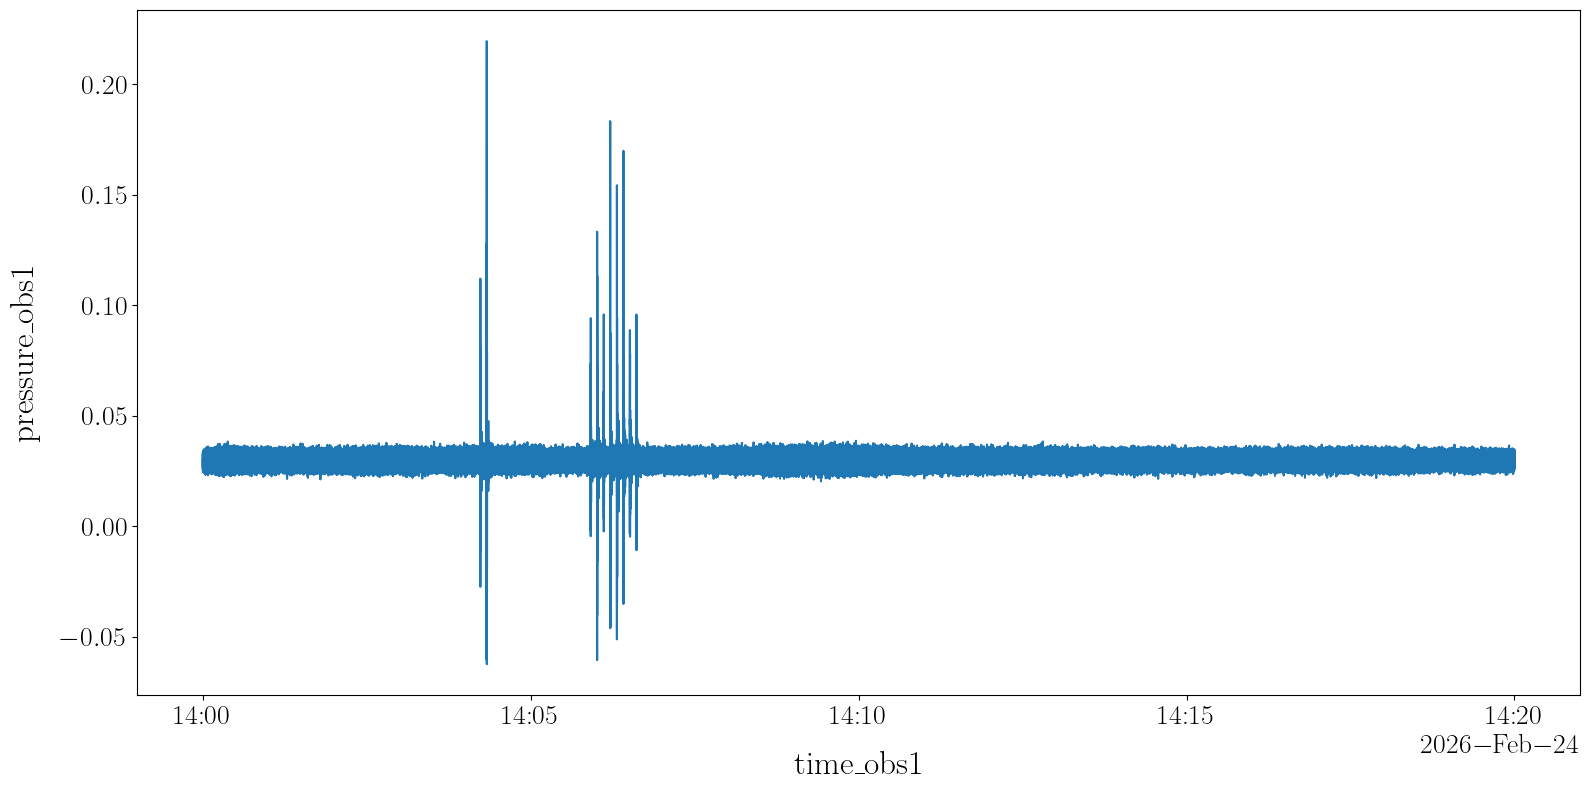

In [19]:
plt.figure()
signal_slice.plot()
